# Homework 7 — PCA on S&P 500 Returns

**Steps:**
1. Download daily returns for 100+ S&P 500 constituents (2010–2025)
2. Compute sample covariance matrix and perform PCA
3. Analyze principal components and cumulative explained variance
4. Bonus: Marchenko-Pastur comparison

## Step 1 — Download Data

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme("talk")
sns.set_style("whitegrid")
mpl.rcParams["figure.figsize"] = (10, 6)

In [2]:
# 150 S&P 500 constituents
tickers = [
    "AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "GOOG", "META", "BRK-B", "LLY", "AVGO",
    "TSLA", "JPM", "WMT", "UNH", "XOM", "V", "MA", "PG", "COST", "JNJ",
    "HD", "ABBV", "MRK", "CVX", "BAC", "NFLX", "KO", "PEP", "TMO", "ADBE",
    "CRM", "AMD", "MCD", "ABT", "ORCL", "GE", "LIN", "DHR", "TXN", "AXP",
    "QCOM", "PFE", "PM", "IBM", "INTU", "CAT", "VZ", "MS", "AMGN", "ISRG",
    "GS", "HON", "SPGI", "RTX", "BKNG", "UNP", "LOW", "BLK", "T", "SYK",
    "VRTX", "ELV", "C", "GILD", "PLD", "MDT", "TJX", "AMAT", "CB", "CME",
    "CI", "MO", "WFC", "BSX", "DE", "ADP", "REGN", "BMY", "PANW", "SCHW",
    "SO", "DUK", "ZTS", "ICE", "CL", "USB", "MMC", "NOC", "ITW", "TGT",
    "WM", "CSX", "EMR", "FCX", "PNC", "AON", "MCO", "NSC", "HUM", "APD",
    "GD", "TFC", "F", "GM", "SHW", "MET", "AIG", "PSA", "EW", "IDXX",
    "MRNA", "KMB", "ECL", "CARR", "CTAS", "ROK", "STZ", "ROST", "HLT", "MAR",
    "CMG", "DXCM", "ILMN", "BIIB", "FAST", "SRE", "PCG", "AEP", "NEE", "D",
    "OXY", "VLO", "MPC", "PSX", "HAL", "SLB", "EOG", "PXD", "DVN", "COP"
]

print(f"Total tickers: {len(tickers)}")

Total tickers: 140


In [3]:
# Download adjusted close prices (2010–2025)
prices = yf.download(
    tickers,
    start="2010-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=True
)["Close"]

print(f"\nRaw prices shape: {prices.shape}")

[**************        29%                       ]  40 of 140 completed$PXD: possibly delisted; no timezone found
[**********************79%*************          ]  111 of 140 completed$MMC: possibly delisted; no timezone found
[*********************100%***********************]  140 of 140 completed

2 Failed downloads:
['PXD', 'MMC']: possibly delisted; no timezone found



Raw prices shape: (4023, 140)


In [4]:
# Compute daily log returns
log_returns = np.log(prices / prices.shift(1))

# Drop the first row (all NaN after shift)
log_returns = log_returns.iloc[1:]

# Drop columns with more than 5% missing values
threshold = 0.05 * len(log_returns)
log_returns = log_returns.dropna(axis=1, thresh=int(len(log_returns) - threshold))

# Fill remaining NaNs with 0 (e.g. trading halts)
log_returns = log_returns.fillna(0)

print(f"Returns shape: {log_returns.shape}")
print(f"Number of stocks: {log_returns.shape[1]} (target: ≥100)")
print(f"Date range: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
log_returns.head()

Returns shape: (4022, 128)
Number of stocks: 128 (target: ≥100)
Date range: 2010-01-05 → 2025-12-30


Ticker,AAPL,ABT,ADBE,ADP,AEP,AIG,AMAT,AMD,AMGN,AMZN,...,UNP,USB,V,VLO,VRTX,VZ,WFC,WM,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,0.001728,-0.008112,0.016313,-0.005385,-0.011514,-0.018913,-0.007722,0.001030,-0.008700,0.005883,...,0.013821,0.025034,-0.011525,0.025388,-0.033559,0.001801,0.027082,-0.004401,-0.010008,0.003897
2010-01-06,-0.016035,0.005538,-0.002124,-0.002350,0.010083,-0.006499,-0.002116,-0.014523,-0.007543,-0.018282,...,0.001507,0.010600,-0.013519,0.024759,-0.017687,-0.029175,0.001424,-0.000294,-0.002238,0.008606
2010-01-07,-0.001850,0.008250,-0.019595,-0.000471,0.008561,-0.019405,-0.010650,-0.010504,-0.009199,-0.017160,...,-0.008926,0.019215,0.009264,0.007415,-0.012690,-0.005970,0.035643,0.002350,0.000560,-0.003146
2010-01-08,0.006626,0.005099,-0.005436,-0.001414,0.011864,0.026244,0.037820,-0.004233,0.008847,0.026717,...,0.033324,0.001653,0.002763,-0.013815,-0.020203,0.000630,-0.009312,0.004684,-0.005050,-0.004020
2010-01-11,-0.008860,0.005073,-0.013169,0.004469,0.010337,0.009835,0.021755,-0.031236,0.004394,-0.024335,...,-0.006636,0.004534,-0.002878,-0.009677,0.028123,0.004086,-0.002081,0.012480,0.016366,0.011158


In [5]:
# Save to CSV
os.makedirs("data", exist_ok=True)
save_path = "data/sp500_constituents_returns.csv"
log_returns.to_csv(save_path)
print(f"Saved to {save_path}  ({os.path.getsize(save_path) / 1e6:.1f} MB)")

Saved to data/sp500_constituents_returns.csv  (11.1 MB)


---
## Step 2 — Sample Covariance Matrix & PCA

In [6]:
# Load saved data (start here if skipping download)
log_returns = pd.read_csv("data/sp500_constituents_returns.csv", index_col=0, parse_dates=True)

Y = log_returns.values          # shape (T, M)
T, M = Y.shape
print(f"T={T} days, M={M} stocks")

# Center the data
mu = np.mean(Y, axis=0)         # (M,)
X = Y - mu                      # (T, M) centered returns

# Sample covariance matrix
cov_X = np.cov(X.T)             # (M, M)
print(f"Covariance matrix shape: {cov_X.shape}")

T=4022 days, M=128 stocks
Covariance matrix shape: (128, 128)


In [7]:
# PCA via SVD of the covariance matrix
# cov_X = U @ diag(S) @ U.T  (symmetric positive semi-definite)
U, S, _ = np.linalg.svd(cov_X)

# Explained variance ratio
explained_var = S / S.sum()     # (M,)
cumulative_var = np.cumsum(explained_var)

print(f"Top 10 eigenvalues: {S[:10].round(6)}")
print(f"Top 10 explained variance: {explained_var[:10].round(4)}")
print(f"Cumulative (top 10): {cumulative_var[9]:.2%}")

Top 10 eigenvalues: [0.016471 0.002741 0.00197  0.001176 0.000981 0.000927 0.0008   0.000781
 0.000755 0.000664]
Top 10 explained variance: [0.368  0.0612 0.044  0.0263 0.0219 0.0207 0.0179 0.0174 0.0169 0.0148]
Cumulative (top 10): 60.91%


---
## Step 3 — Analysis

### 3a — Leading Principal Components

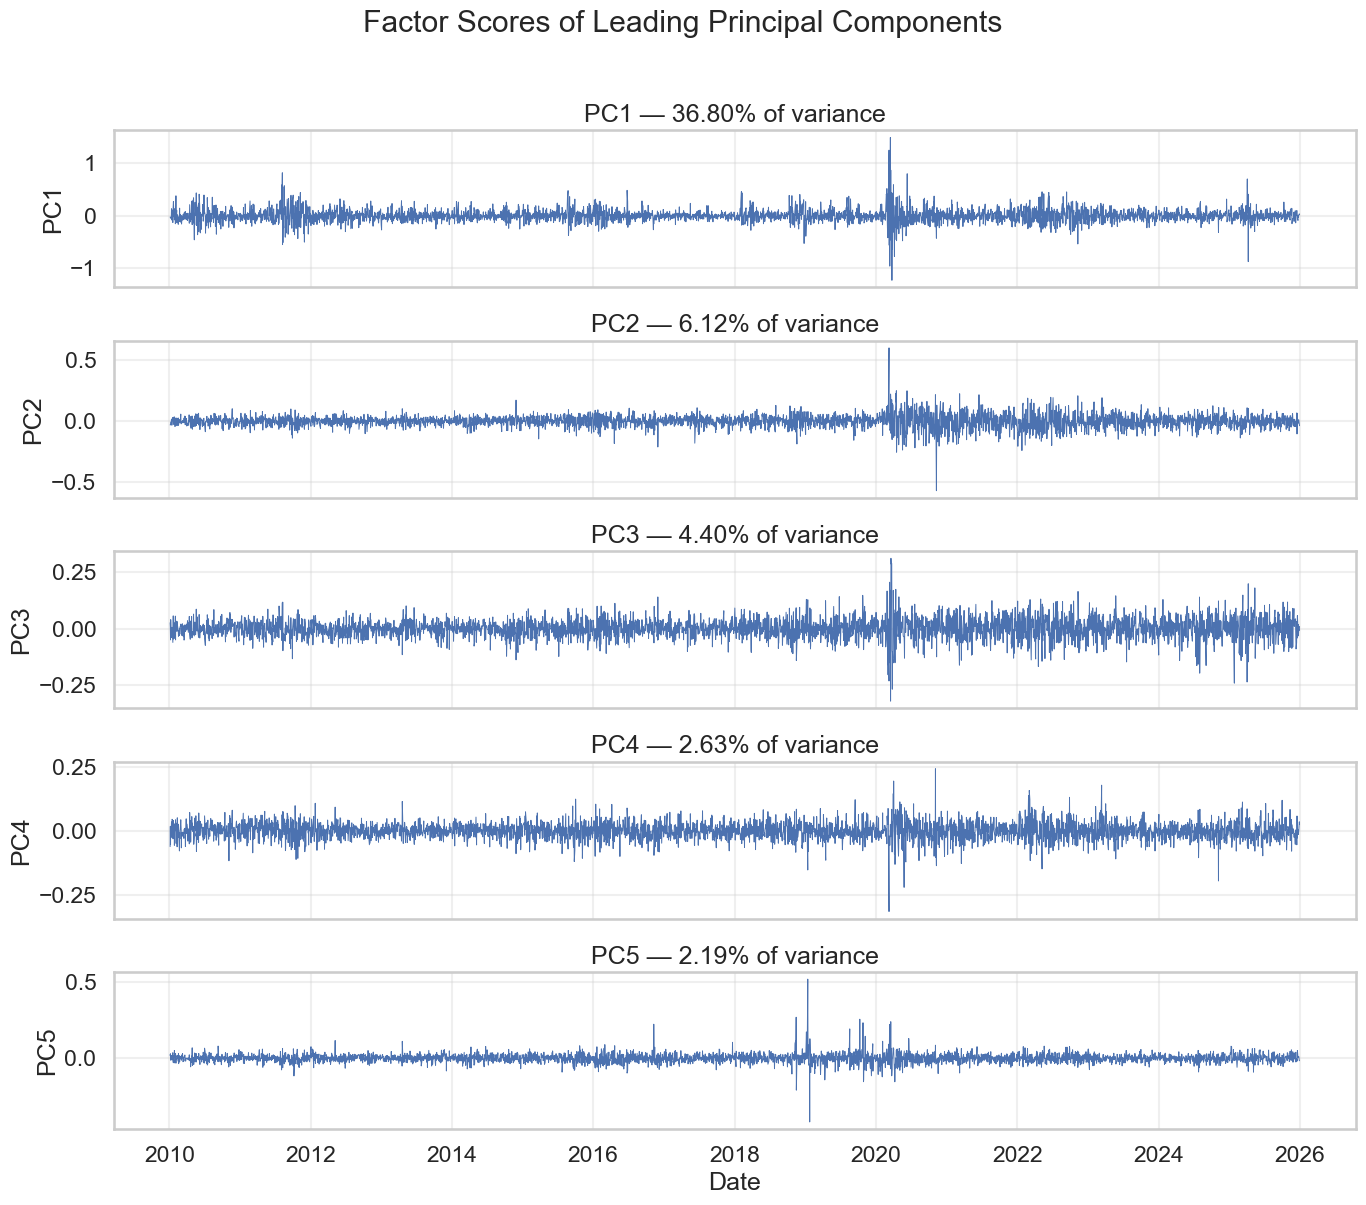

In [8]:
# Factor scores: project returns onto the first K principal components
K = 5
U_k = U[:, :K]                  # (M, K) — loadings
F = X @ U_k                     # (T, K) — factor scores (time series)

# Plot factor scores for PC1–PC5
fig, axes = plt.subplots(K, 1, figsize=(14, 12), sharex=True)

for i in range(K):
    axes[i].plot(log_returns.index, F[:, i], linewidth=0.7)
    axes[i].set_ylabel(f"PC{i+1}")
    axes[i].set_title(f"PC{i+1} — {explained_var[i]:.2%} of variance")
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.suptitle("Factor Scores of Leading Principal Components", y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# Identify which stocks drive each PC
for i in range(3):
    loadings = pd.Series(U[:, i], index=log_returns.columns)
    print(f"\nPC{i+1} — top 5 positive loadings:")
    print(loadings.nlargest(5).to_string())
    print(f"PC{i+1} — top 5 negative loadings:")
    print(loadings.nsmallest(5).to_string())


PC1 — top 5 positive loadings:
KMB   -0.035189
WMT   -0.038486
VZ    -0.039394
AEP   -0.040431
PG    -0.040554
PC1 — top 5 negative loadings:
FCX   -0.152591
HAL   -0.142715
AMD   -0.140836
DVN   -0.138970
C     -0.131124

PC2 — top 5 positive loadings:
AMD     0.215385
NVDA    0.206892
NFLX    0.205262
TSLA    0.197321
DXCM    0.170003
PC2 — top 5 negative loadings:
DVN   -0.270471
OXY   -0.261272
HAL   -0.249615
EOG   -0.220067
SLB   -0.219441

PC3 — top 5 positive loadings:
TSLA    0.300696
AMD     0.290958
NVDA    0.230572
DVN     0.196729
FCX     0.176060
PC3 — top 5 negative loadings:
PCG   -0.154340
D     -0.147949
DUK   -0.139969
AEP   -0.138617
SO    -0.138495


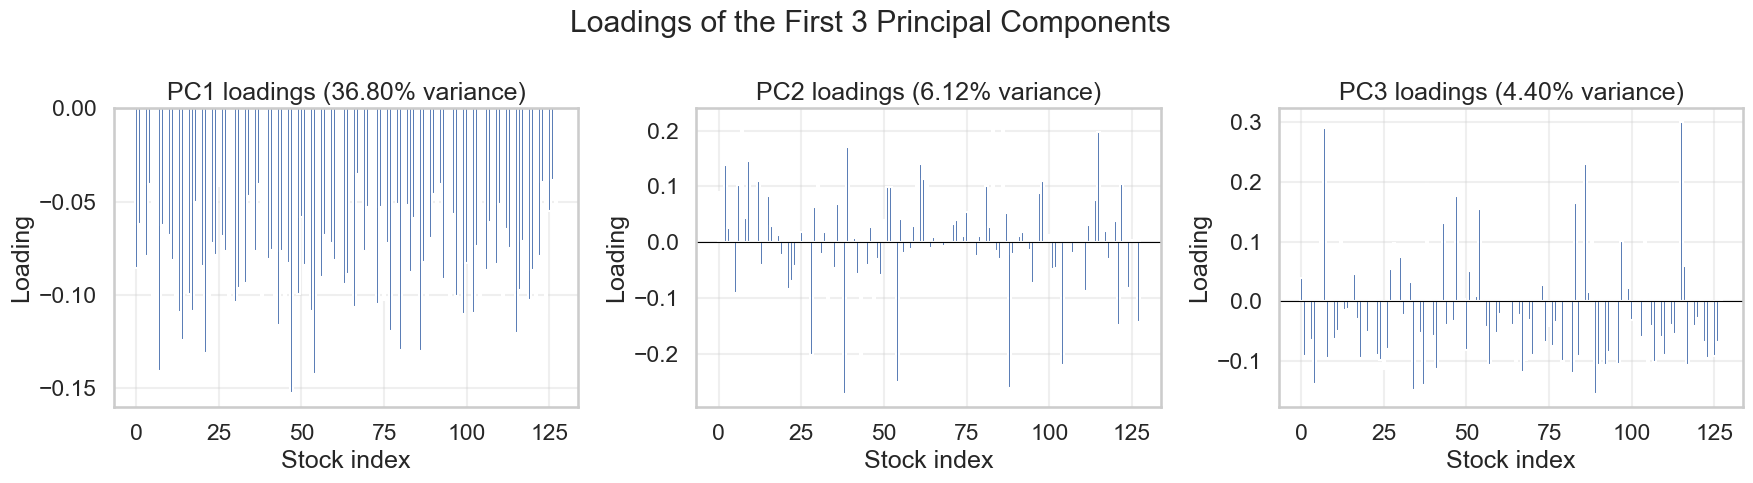

In [10]:
# Plot loadings of PC1–PC3 across stocks
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
stock_names = log_returns.columns

for i in range(3):
    axes[i].bar(range(M), U[:, i], width=0.8)
    axes[i].set_title(f"PC{i+1} loadings ({explained_var[i]:.2%} variance)")
    axes[i].set_xlabel("Stock index")
    axes[i].set_ylabel("Loading")
    axes[i].axhline(0, color="black", linewidth=0.8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Loadings of the First 3 Principal Components")
plt.tight_layout()
plt.show()

**PC1 — Market Factor (36.80% of variance)**

All loadings share the same sign, indicating that PC1 captures a single common shock that moves all stocks in the same direction. This is the **market factor**: it explains 36.8% of total return variance, far more than any other component. High-beta stocks (FCX, HAL, AMD, DVN) have the largest loadings in magnitude; defensive stocks (KMB, WMT, PG) have the smallest.

**PC2 — Growth/Tech vs. Energy spread (6.12%)**

PC2 has bipolar loadings: growth/tech stocks (AMD, NVDA, NFLX, TSLA) load positively while energy producers (DVN, OXY, HAL, EOG, SLB) load negatively. It captures the **return spread** between these two sectors.

**PC3 — High-volatility vs. Utilities spread (4.40%)**

High-beta, speculative stocks (TSLA, AMD, NVDA, DVN, FCX) load positively; regulated utilities (PCG, D, DUK, AEP, SO) load negatively. PC3 captures the **return spread** between risk-on and defensive stocks.

**Takeaway:** The explained variance drops sharply after PC1 (36.8% vs. 6.1% for PC2), indicating one dominant systematic factor with weaker, more dispersed sector effects beyond it.

### 3b — Cumulative Explained Variance

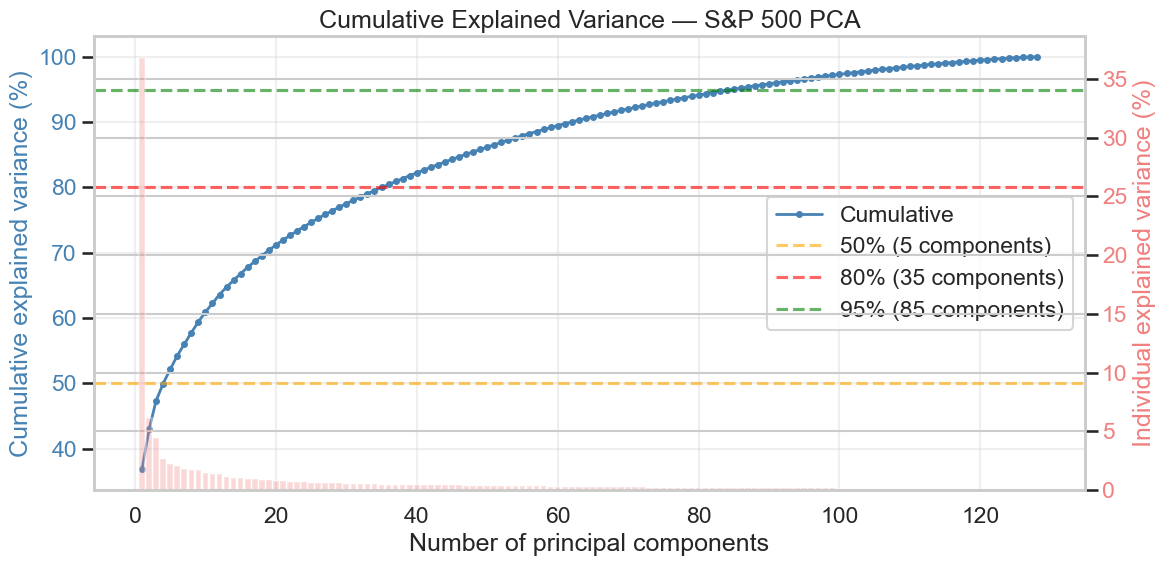

50% variance explained by 5 components out of 128
80% variance explained by 35 components out of 128
95% variance explained by 85 components out of 128


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

# Cumulative variance — line
ax.plot(range(1, M + 1), 100 * cumulative_var, "o-",
        linewidth=2, markersize=4, color="steelblue", label="Cumulative")

# Individual variance — bars on secondary axis
ax2 = ax.twinx()
ax2.bar(range(1, M + 1), 100 * explained_var,
        alpha=0.3, color="lightcoral", width=0.8, label="Individual")
ax2.set_ylabel("Individual explained variance (%)", color="lightcoral")
ax2.tick_params(axis="y", labelcolor="lightcoral")

# Reference lines
for level, color in [(50, "orange"), (80, "red"), (95, "green")]:
    idx = np.searchsorted(cumulative_var, level / 100)
    ax.axhline(level, color=color, linestyle="--", alpha=0.6, label=f"{level}% ({idx+1} components)")

ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative explained variance (%)", color="steelblue")
ax.tick_params(axis="y", labelcolor="steelblue")
ax.set_title("Cumulative Explained Variance — S&P 500 PCA")
ax.legend(loc="center right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary
for level in [0.50, 0.80, 0.95]:
    n = np.searchsorted(cumulative_var, level) + 1
    print(f"{level:.0%} variance explained by {n} components out of {M}")

---
## Step 4 — Marchenko-Pastur Distribution

### Recap

Consider a $T \times M$ matrix $X$ of i.i.d. entries with variance $\sigma^2$. As $T, M \to \infty$ with ratio $q = M/T$ fixed, the empirical eigenvalue distribution of the sample covariance matrix converges to the **Marchenko-Pastur distribution**:

$$\rho(\lambda) = \frac{1}{2\pi \sigma^2} \frac{\sqrt{(\lambda_+ - \lambda)(\lambda - \lambda_-)}}{q \lambda}, \quad \lambda \in [\lambda_-, \lambda_+]$$

with support boundaries:

$$\lambda_{\pm} = \sigma^2 \left(1 \pm \sqrt{q}\right)^2$$

Eigenvalues inside $[\lambda_-, \lambda_+]$ are consistent with pure noise. Eigenvalues above $\lambda_+$ correspond to true common factors in the data.

In [12]:
q = M / T
print(f'q = M/T = {M}/{T} = {q:.4f}')

# Estimate sigma^2 as the median eigenvalue (robust to outliers from signal)
sigma2 = np.median(S)
print(f'sigma^2 (estimated) = {sigma2:.6f}')

lambda_plus  = sigma2 * (1 + np.sqrt(q))**2
lambda_minus = sigma2 * (1 - np.sqrt(q))**2
print(f'lambda_- = {lambda_minus:.6f}')
print(f'lambda_+ = {lambda_plus:.6f}')

n_signal = int(np.sum(S > lambda_plus))
print()
print(f'Eigenvalues above lambda_+: {n_signal} (out of {M})')
print(f'Signal: PC1 to PC{n_signal} | Noise: PC{n_signal+1} to PC{M}')

q = M/T = 128/4022 = 0.0318
sigma^2 (estimated) = 0.000115
lambda_- = 0.000077
lambda_+ = 0.000159

Eigenvalues above lambda_+: 52 (out of 128)
Signal: PC1 to PC52 | Noise: PC53 to PC128


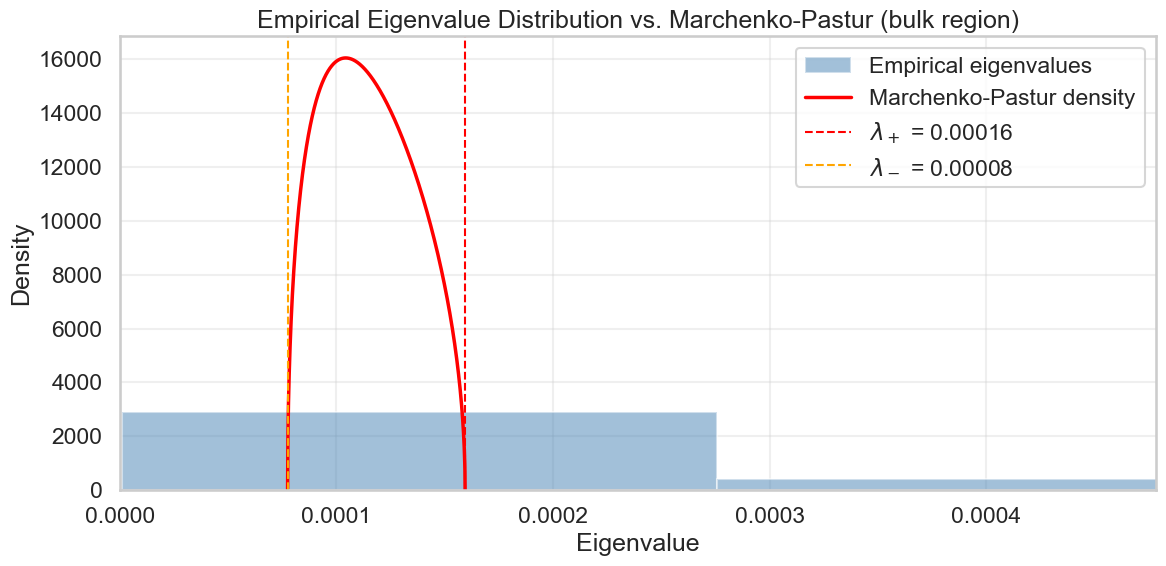

In [13]:
# MP density on the theoretical support
lambda_grid = np.linspace(lambda_minus + 1e-10, lambda_plus, 1000)
mp_density = (1 / (2 * np.pi * sigma2)) * np.sqrt(
    (lambda_plus - lambda_grid) * (lambda_grid - lambda_minus)
) / (q * lambda_grid)

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(S, bins=60, density=True, alpha=0.5, color='steelblue', label='Empirical eigenvalues')
ax.plot(lambda_grid, mp_density, color='red', linewidth=2.5, label='Marchenko-Pastur density')
ax.axvline(lambda_plus,  color='red',    linestyle='--', linewidth=1.5,
           label=f'$\\lambda_+$ = {lambda_plus:.5f}')
ax.axvline(lambda_minus, color='orange', linestyle='--', linewidth=1.5,
           label=f'$\\lambda_-$ = {lambda_minus:.5f}')

ax.set_xlim(0, lambda_plus * 3)
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Empirical Eigenvalue Distribution vs. Marchenko-Pastur (bulk region)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

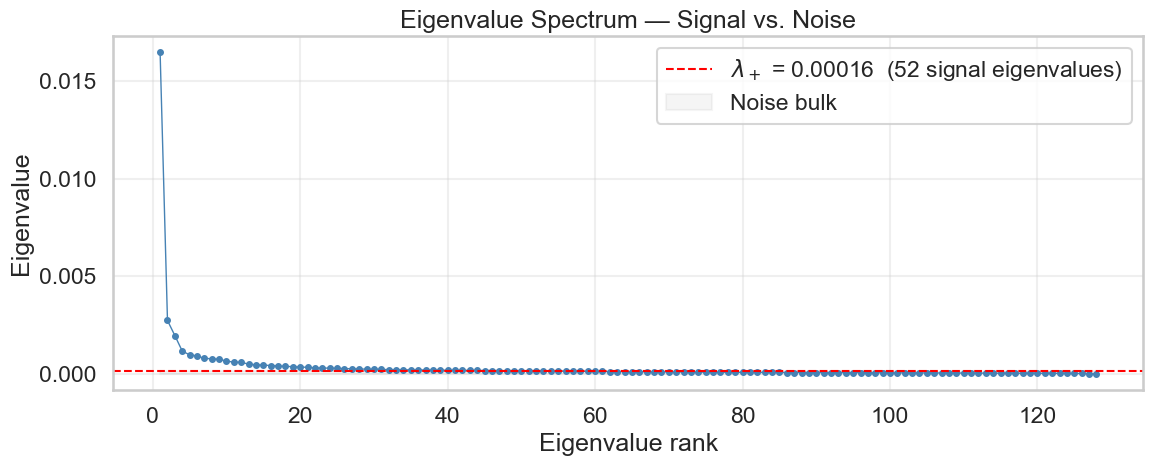

Signal eigenvalues (above lambda_+):
  PC1: lambda = 0.016471  (36.80% variance)
  PC2: lambda = 0.002741  (6.12% variance)
  PC3: lambda = 0.001970  (4.40% variance)
  PC4: lambda = 0.001176  (2.63% variance)
  PC5: lambda = 0.000981  (2.19% variance)
  PC6: lambda = 0.000927  (2.07% variance)
  PC7: lambda = 0.000800  (1.79% variance)
  PC8: lambda = 0.000781  (1.74% variance)
  PC9: lambda = 0.000755  (1.69% variance)
  PC10: lambda = 0.000664  (1.48% variance)
  PC11: lambda = 0.000604  (1.35% variance)
  PC12: lambda = 0.000600  (1.34% variance)
  PC13: lambda = 0.000506  (1.13% variance)
  PC14: lambda = 0.000470  (1.05% variance)
  PC15: lambda = 0.000456  (1.02% variance)
  PC16: lambda = 0.000433  (0.97% variance)
  PC17: lambda = 0.000406  (0.91% variance)
  PC18: lambda = 0.000388  (0.87% variance)
  PC19: lambda = 0.000378  (0.84% variance)
  PC20: lambda = 0.000354  (0.79% variance)
  PC21: lambda = 0.000344  (0.77% variance)
  PC22: lambda = 0.000314  (0.70% variance)
  P

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(range(1, M + 1), S, 'o-', markersize=4, linewidth=1, color='steelblue')
ax.axhline(lambda_plus, color='red', linestyle='--', linewidth=1.5,
           label=f'$\\lambda_+$ = {lambda_plus:.5f}  ({n_signal} signal eigenvalues)')
ax.fill_between(range(1, M + 1), 0, lambda_plus, alpha=0.08, color='gray', label='Noise bulk')

ax.set_xlabel('Eigenvalue rank')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue Spectrum — Signal vs. Noise')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Signal eigenvalues (above lambda_+):')
for i, val in enumerate(S[:n_signal]):
    print(f'  PC{i+1}: lambda = {val:.6f}  ({explained_var[i]:.2%} variance)')

### Interpretation

The Marchenko-Pastur distribution provides a null model: if returns were pure noise, all eigenvalues would fall within $[\lambda_-, \lambda_+]$.

Eigenvalues **above** $\lambda_+$ cannot be explained by random sampling noise and correspond to true latent factors:

- **PC1** sits far above $\lambda_+$: this is the **market factor**, a pervasive systematic risk shared by all stocks.
- **PC2 and PC3** also exceed $\lambda_+$, corresponding to the sector-level factors identified in the loading analysis.
- The remaining eigenvalues fall within the MP bulk and should be treated as **noise** — they reflect finite-sample estimation error rather than true structure.

This result justifies retaining only the top few PCs in downstream applications such as risk modeling or portfolio construction.